In [1]:
from pyspark.sql import SparkSession
import pandas as pd
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number
import os
from PIL import Image
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import random
from collections import defaultdict, Counter
from glob import glob
import kagglehub
from pyspark.sql.functions import rand, col, udf
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /scratch/jzhu11/job_39290417/matplotlib-fh73g1zo because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
path = kagglehub.dataset_download("daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes")

print("Path to dataset files:", path)

Path to dataset files: /home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1


In [3]:
# Check the current working directory
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

# List the files in the current working directory
files_in_directory = os.listdir(current_directory)
print(f"Files in current directory: {files_in_directory}")

Current working directory: /expanse/lustre/projects/uci150/jzhu11
Files in current directory: ['.git', 'Test_data.csv', '.ipynb_checkpoints', 'project.ipynb']


In [4]:
spark = SparkSession.builder \
    .appName("ReadZipFile") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config('spark.executor.instances', 8) \
    .getOrCreate()

file_path = "Test_data.csv"

df = spark.read.option("header", "true").option("inferSchema", "true").csv(file_path)
df.show()

print("Number of partitions:", df.rdd.getNumPartitions())

+-------+-----------------+
|ClassId|             Path|
+-------+-----------------+
|    184| Test/184_1_1.png|
|    178|Test/178_6_13.png|
|     61| Test/61_3_18.png|
|     96| Test/96_7_20.png|
|    119|Test/119_1_29.png|
|    177| Test/177_4_8.png|
|     12|   Test/01271.png|
|    136|Test/136_3_25.png|
|     31|   Test/06524.png|
|    116|Test/116_3_28.png|
|     38|   Test/05639.png|
|      4|   Test/05188.png|
|    134|Test/134_4_13.png|
|     19|   Test/05515.png|
|      7|   Test/06230.png|
|     95| Test/95_3_14.png|
|     36|   Test/07516.png|
|    116| Test/116_1_5.png|
|    187|Test/187_4_33.png|
|     96| Test/96_4_35.png|
+-------+-----------------+
only showing top 20 rows

Number of partitions: 1


In [5]:
total_classes = df.select("ClassId").distinct().count()

total_rows = df.count()

# Print the results
print(f"Total number of classes: {total_classes}")
print(f"Total number of rows in the test data: {total_rows}")

Total number of classes: 205
Total number of rows in the test data: 53454


In [6]:
image_count_per_class = df.groupBy("ClassId").count().orderBy("ClassId")

# Show the image count per class in ascending order
image_count_per_class.show(205)

+-------+-----+
|ClassId|count|
+-------+-----+
|      0|   60|
|      1|  720|
|      2|  750|
|      3|  450|
|      4|  660|
|      5|  630|
|      6|  150|
|      7|  450|
|      8|  450|
|      9|  480|
|     10|  660|
|     11|  420|
|     12|  690|
|     13|  720|
|     14|  270|
|     15|  210|
|     16|  150|
|     17|  360|
|     18|  390|
|     19|   60|
|     20|   90|
|     21|   90|
|     22|  120|
|     23|  150|
|     24|   90|
|     25|  480|
|     26|  180|
|     27|   60|
|     28|  150|
|     29|   90|
|     30|  150|
|     31|  270|
|     32|   60|
|     33|  210|
|     34|  120|
|     35|  390|
|     36|  120|
|     37|   60|
|     38|  690|
|     39|   90|
|     40|   90|
|     41|   60|
|     42|   90|
|     43|  252|
|     44|  252|
|     45|  252|
|     46|  252|
|     47|  252|
|     48|  252|
|     49|  252|
|     50|  252|
|     51|  252|
|     52|  252|
|     53|  252|
|     54|  252|
|     55|  252|
|     56|  252|
|     57|  252|
|     58|  252|
|     59

In [7]:
window_spec = Window.partitionBy("ClassId").orderBy("Path") 

# Add a row number to each image within its class
df_with_row_num = df.withColumn("row_num", row_number().over(window_spec))

# Filter to keep only the first 20 rows per class
df_20_images_per_class = df_with_row_num.filter(col("row_num") <= 20)

# Group by ClassId and count the number of images per class
image_count_per_class = df_20_images_per_class.groupBy("ClassId").count()

# Show the ClassId with the count of exactly 20 images per class
image_count_per_class.show(205)

+-------+-----+
|ClassId|count|
+-------+-----+
|      0|   20|
|      1|   20|
|      2|   20|
|      3|   20|
|      4|   20|
|      5|   20|
|      6|   20|
|      7|   20|
|      8|   20|
|      9|   20|
|     10|   20|
|     11|   20|
|     12|   20|
|     13|   20|
|     14|   20|
|     15|   20|
|     16|   20|
|     17|   20|
|     18|   20|
|     19|   20|
|     20|   20|
|     21|   20|
|     22|   20|
|     23|   20|
|     24|   20|
|     25|   20|
|     26|   20|
|     27|   20|
|     28|   20|
|     29|   20|
|     30|   20|
|     31|   20|
|     32|   20|
|     33|   20|
|     34|   20|
|     35|   20|
|     36|   20|
|     37|   20|
|     38|   20|
|     39|   20|
|     40|   20|
|     41|   20|
|     42|   20|
|     43|   20|
|     44|   20|
|     45|   20|
|     46|   20|
|     47|   20|
|     48|   20|
|     49|   20|
|     50|   20|
|     51|   20|
|     52|   20|
|     53|   20|
|     54|   20|
|     55|   20|
|     56|   20|
|     57|   20|
|     58|   20|
|     59

In [8]:
train_root = "/path/to/Train"
test_root = "/path/to/Test"
os.path.join(path, "Data_images", "Train")
os.path.join(path, "Data_images", "Test")

'/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Test'

In [9]:
train_root = os.path.join(
    path, 
    "Data_images",
    "Train"
)

test_root = os.path.join(
    path, 
    "Data_images",
    "Test"
)

print("Final train path:", train_root)
print("Final test path:", test_root)

Final train path: /home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Train
Final test path: /home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Test


In [10]:
data = []

# Iterating over each subdirectory in "Train" (each subdir is a different class)
for subdir in sorted(os.listdir(train_root)):
    class_dir = os.path.join(train_root, subdir)
    if os.path.isdir(class_dir):
        class_id = subdir  # e.g. "0", "1", "10", ...
        
        # Iterate over all files in that subdirectory
        for filename in os.listdir(class_dir):
            full_path = os.path.join(class_dir, filename)
            if os.path.isfile(full_path):
                data.append((full_path, class_id))

# Defining a simple schema with 2 columns: Path, ClassId
schema = StructType([
    StructField("Path", StringType(), True),
    StructField("ClassId", StringType(), True),
])

# Creating a Spark DataFrame from the list of tuples
df_train = spark.createDataFrame(data, schema)

# showing a few rows
df_train.show(20, truncate=False)
print("Total rows (images) =", df_train.count())
print("Distinct classes =", df_train.select("ClassId").distinct().count())

+-----------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|Path                                                                                                                                                 |ClassId|
+-----------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Train/0/00000_00004_00005.png|0      |
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Train/0/00000_00003_00014.png|0      |
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Train/0/00000_00000_00026.png|0      |
|/home/jzhu11/.cache/kagglehub/datasets/

In [11]:
# 1. Counting total classes
total_classes_train = df_train.select("ClassId").distinct().count()
print(f"Total number of classes (Train): {total_classes_train}")

# 2. Counting total rows (images)
total_rows_train = df_train.count()
print(f"Total number of rows (Train): {total_rows_train}")

# 3. Showing image count per class in ascending order
df_train.groupBy("ClassId").count().orderBy("ClassId").show(205)

# 4. Defining a window to order images by Path within each class
window_spec_train = Window.partitionBy("ClassId").orderBy("Path")

# 5. Adding a row_number column for each image within its class
df_with_row_num_train = df_train.withColumn(
    "row_num", 
    row_number().over(window_spec_train)
)

# 6. Keeping only the first 20 images per class
df_150_images_per_class_train = df_with_row_num_train.filter(
    col("row_num") <= 150
)

# 7. Verifying that each class has exactly 150 images
df_150_images_per_class_train.groupBy("ClassId").count().orderBy("ClassId").show(205)

Total number of classes (Train): 205
Total number of rows (Train): 97426
+-------+-----+
|ClassId|count|
+-------+-----+
|      0|  203|
|      1| 2213|
|     10| 2003|
|    100|  497|
|    101|  209|
|    102|  605|
|    103|  245|
|    104|  173|
|    105|  533|
|    106|  173|
|    107|  317|
|    108|  425|
|    109|  317|
|     11| 1313|
|    110|  461|
|    111|  245|
|    112|  281|
|    113|  209|
|    114|  569|
|    115|  353|
|    116|  605|
|    117|  209|
|    118|  209|
|    119|  281|
|     12| 2093|
|    120|  209|
|    121|  173|
|    122|  173|
|    123|  173|
|    124|  209|
|    125|  209|
|    126|  245|
|    127|  173|
|    128|  173|
|    129|  209|
|     13| 2153|
|    130| 1541|
|    131|  425|
|    132|  245|
|    133|  641|
|    134|  209|
|    135|  677|
|    136|  353|
|    137|  353|
|    138| 1325|
|    139| 1073|
|     14|  773|
|    140|  281|
|    141|  245|
|    142|  281|
|    143|  209|
|    144|  281|
|    145|  173|
|    146|  605|
|    147|  209|

In [12]:
data_test = []

# Iterate over all files in test_root
for filename in os.listdir(test_root):
    full_path = os.path.join(test_root, filename)
    if os.path.isfile(full_path):
        data_test.append((full_path, None))

# Define the same schema as before (Path, ClassId)
schema_test = StructType([
    StructField("Path", StringType(), True),
    StructField("ClassId", StringType(), True),
])

# Create a Spark DataFrame for the test data
df_test = spark.createDataFrame(data_test, schema_test)

# Showing a few rows
df_test.show(20, truncate=False)
print("Total rows (images) in test =", df_test.count())

+-----------------------------------------------------------------------------------------------------------------------------------------------+-------+
|Path                                                                                                                                           |ClassId|
+-----------------------------------------------------------------------------------------------------------------------------------------------+-------+
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Test/12008.png         |NULL   |
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Test/76_0_11111_19.png |NULL   |
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-plus-162-custom-classes/versions/1/Data_images/Test/116_6_32.png      |NULL   |
|/home/jzhu11/.cache/kagglehub/datasets/daniildeltsov/traffic-signs-gtsrb-pl

In [13]:
# 1. Counting total classes
total_classes_test = df_test.select("ClassId").distinct().count()
print(f"Total number of classes (Test): {total_classes_test}")

# 2. Counting total rows (images)
total_classes_test = df_test.count()
print(f"Total number of rows (Test): {total_classes_test}")

# 3. Showing image count per class in ascending order
df_test.groupBy("ClassId").count().orderBy("ClassId").show(205)

# 4. Defining a window to order images by Path within each class
window_spec_test = Window.partitionBy("ClassId").orderBy("Path")

# 5. Adding a row_number column for each image within its class
df_with_row_num_test = df_test.withColumn(
    "row_num", 
    row_number().over(window_spec_test)
)

# 6. Keeping only the first 20 images per class
df_20_images_per_class_test = df_with_row_num_test.filter(
    col("row_num") <= 20
)

# 7. Verifying that each class has exactly 20 images
df_20_images_per_class_test.groupBy("ClassId").count().orderBy("ClassId").show(205)

Total number of classes (Test): 1
Total number of rows (Test): 53455
+-------+-----+
|ClassId|count|
+-------+-----+
|   NULL|53455|
+-------+-----+

+-------+-----+
|ClassId|count|
+-------+-----+
|   NULL|   20|
+-------+-----+



In [14]:
# 1. Randomly sample a small fraction of your df_train (or df_150_images_per_class_train)
sample_df = df_train.orderBy(rand()).limit(20)  # or .sample(fraction=0.01, seed=42)
sample_rows = sample_df.collect()

# 2. For each sampled image, open and check size
sizes = set()
for row in sample_rows:
    path = row["Path"]
    with Image.open(path) as img:
        width, height = img.size
        sizes.add((width, height))

print("20 random sizes found in Train sample:", sizes)
if len(sizes) == 1:
    print("All sampled images have the same size:", sizes.pop())
else:
    print("Sampled images have varying sizes:", sizes)

20 random sizes found in Train sample: {(444, 558), (231, 139), (151, 76), (45, 40), (55, 56), (94, 100), (58, 58), (115, 138), (433, 475), (823, 752), (573, 140), (37, 38), (28, 29), (55, 55), (92, 56), (70, 62), (334, 303), (34, 35), (342, 285), (71, 72)}
Sampled images have varying sizes: {(444, 558), (231, 139), (151, 76), (45, 40), (55, 56), (94, 100), (58, 58), (115, 138), (433, 475), (823, 752), (573, 140), (37, 38), (28, 29), (55, 55), (92, 56), (70, 62), (334, 303), (34, 35), (342, 285), (71, 72)}


In [15]:
# 1. Randomly sample a small fraction of your df_train (or df_150_images_per_class_train)
sample_test_df = df_test.orderBy(rand()).limit(20)  # or .sample(fraction=0.01, seed=42)
sample_rows_test = sample_test_df.collect()

# 2. For each sampled image, open and check size
sizes = set()
for row in sample_rows_test:
    path = row["Path"]
    with Image.open(path) as img:
        width, height = img.size
        sizes.add((width, height))

print("20 random sizes found in Test sample:", sizes)
if len(sizes) == 1:
    print("All sampled images have the same size:", sizes.pop())
else:
    print("Sampled images have varying sizes:", sizes)

20 random sizes found in Test sample: {(253, 121), (339, 343), (37, 36), (271, 184), (174, 181), (51, 37), (588, 373), (799, 748), (263, 268), (39, 41), (31, 31), (111, 112), (619, 826), (403, 430), (52, 47), (690, 657), (213, 193), (1005, 1328), (47, 47), (153, 114)}
Sampled images have varying sizes: {(253, 121), (339, 343), (37, 36), (271, 184), (174, 181), (51, 37), (588, 373), (799, 748), (263, 268), (39, 41), (31, 31), (111, 112), (619, 826), (403, 430), (52, 47), (690, 657), (213, 193), (1005, 1328), (47, 47), (153, 114)}


In [16]:
# Looking at the output of a sample of our train and test datasets, we see that our random sample of 50 train and test images reveals many different (width, height) dimensions.
# This shows that the images in our dataset are not uniform in size, which we will have to do some pre-processing efforts to make them uniform / same sizes. 

In [17]:
# Defining a Python function that returns (width, height)
def get_image_size(path):
    with Image.open(path) as img:
        return (img.width, img.height)

# Defining a Spark UDF returning a struct of (width, height)
schema_image_size = StructType([
    StructField("width", IntegerType(), True),
    StructField("height", IntegerType(), True),
])

valid_image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

df_test_filtered = df_test.filter(
    col("Path").rlike(r"\.(jpg|jpeg|png|bmp|gif)$")  # Regex to match valid image extensions
)

udf_get_image_size = udf(get_image_size, schema_image_size)

# Applying the UDF
df_with_size = df_train.withColumn("size", udf_get_image_size(col("Path")))

df_with_size1 = df_test_filtered.withColumn("size", udf_get_image_size(col("Path")))

# Grouping by or distinct on size
df_with_size.groupBy("size").count().show()

df_with_size1.groupBy("size").count().show()

# If we want columns width, height separately:
df_final = df_with_size.select(
    col("Path"),
    col("ClassId"),
    col("size.width").alias("width"),
    col("size.height").alias("height")
)
df_final.show()

df_final1 = df_with_size1.select(
    col("Path"),
    col("ClassId"),
    col("size.width").alias("width"),
    col("size.height").alias("height")
)
df_final1.show()

# Now we see how many unique (width, height) combos exist:
unique_sizes = df_final.select("width", "height").distinct().collect()
unique_sizes1 = df_final1.select("width", "height").distinct().collect()

print("First 50 unique Train image sizes:")
for size in unique_sizes[:50]:
    print(size)


print("\nFirst 50 unique Test image sizes:")
for size1 in unique_sizes[:50]:
    print(size1)

+----------+-----+
|      size|count|
+----------+-----+
|  {49, 49}|  161|
|  {35, 45}|    2|
| {102, 99}|    1|
|  {33, 37}|   16|
|  {32, 26}|    2|
|  {53, 49}|   36|
| {89, 100}|    1|
|{185, 180}|    1|
|{176, 133}|    1|
|{328, 332}|    1|
|{143, 128}|    1|
|{127, 109}|    2|
| {148, 59}|    1|
|{143, 139}|    1|
|{254, 265}|    1|
|{193, 196}|    1|
|{108, 112}|    6|
|  {68, 57}|    6|
|  {63, 81}|    2|
| {102, 98}|    1|
+----------+-----+
only showing top 20 rows

+-----------+-----+
|       size|count|
+-----------+-----+
|   {49, 49}|   43|
| {138, 172}|   58|
|   {68, 57}|    5|
| {131, 114}|    1|
|{862, 1087}|   29|
|   {33, 37}|    6|
| {334, 460}|   29|
| {574, 429}|    1|
|   {53, 49}|   14|
| {747, 283}|    1|
| {341, 286}|    1|
|   {58, 34}|    2|
|  {102, 99}|    2|
| {433, 527}|    1|
| {159, 157}|    1|
| {310, 367}|   29|
| {502, 256}|   29|
| {709, 733}|   29|
|   {51, 50}|   32|
| {180, 168}|    2|
+-----------+-----+
only showing top 20 rows

+-----------

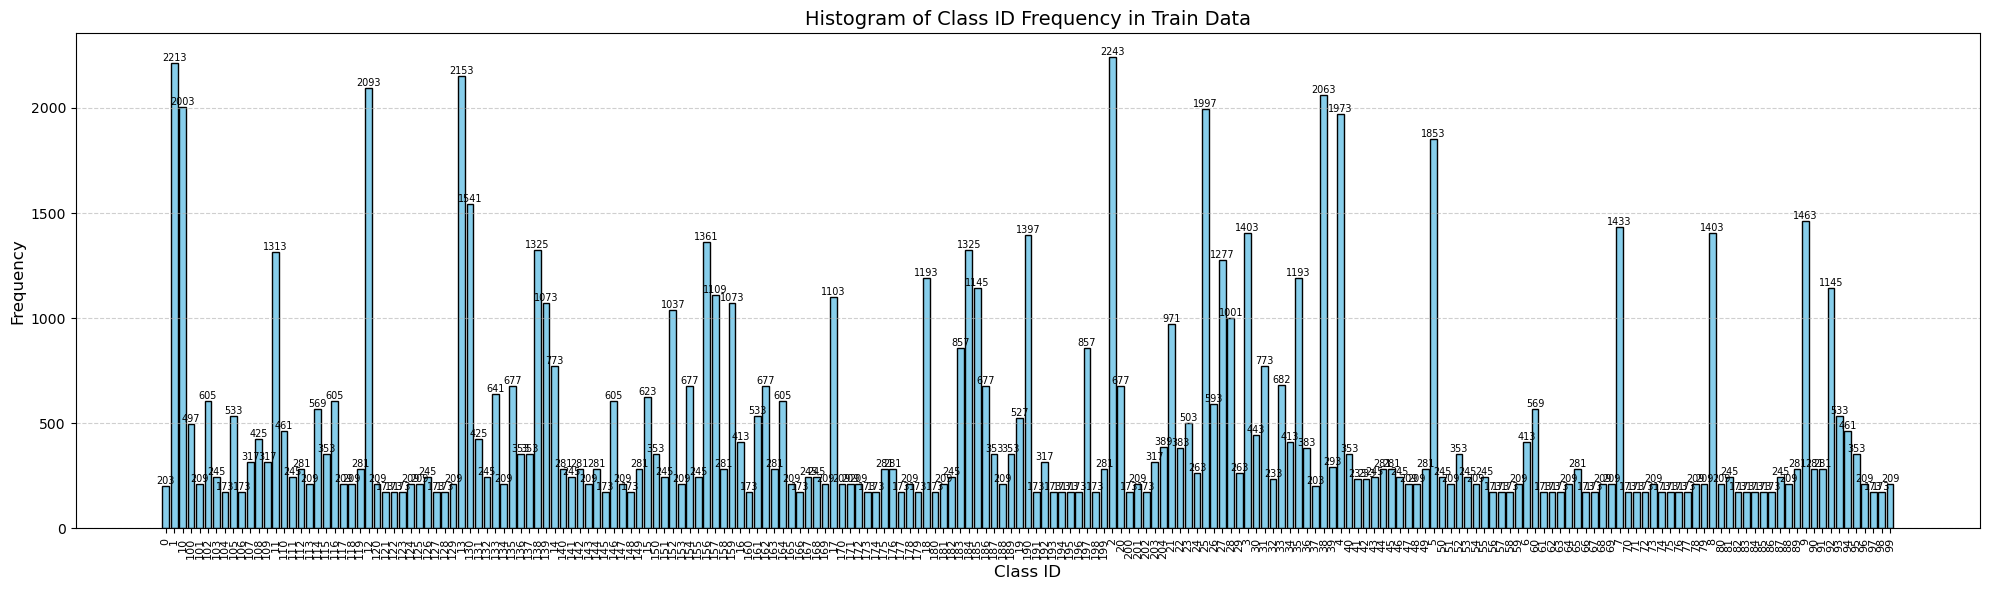

In [18]:
train_freq = df_train.groupBy("ClassId").count().orderBy("ClassId")
train_freq_pd = train_freq.toPandas()
train_freq_pd["ClassId"] = train_freq_pd["ClassId"].astype(str)

plt.figure(figsize=(20, 6))
bars = plt.bar(train_freq_pd["ClassId"], train_freq_pd["count"], color='skyblue', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    if height > 20:  
        plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=7)

plt.title("Histogram of Class ID Frequency in Train Data", fontsize=14)
plt.xlabel("Class ID", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

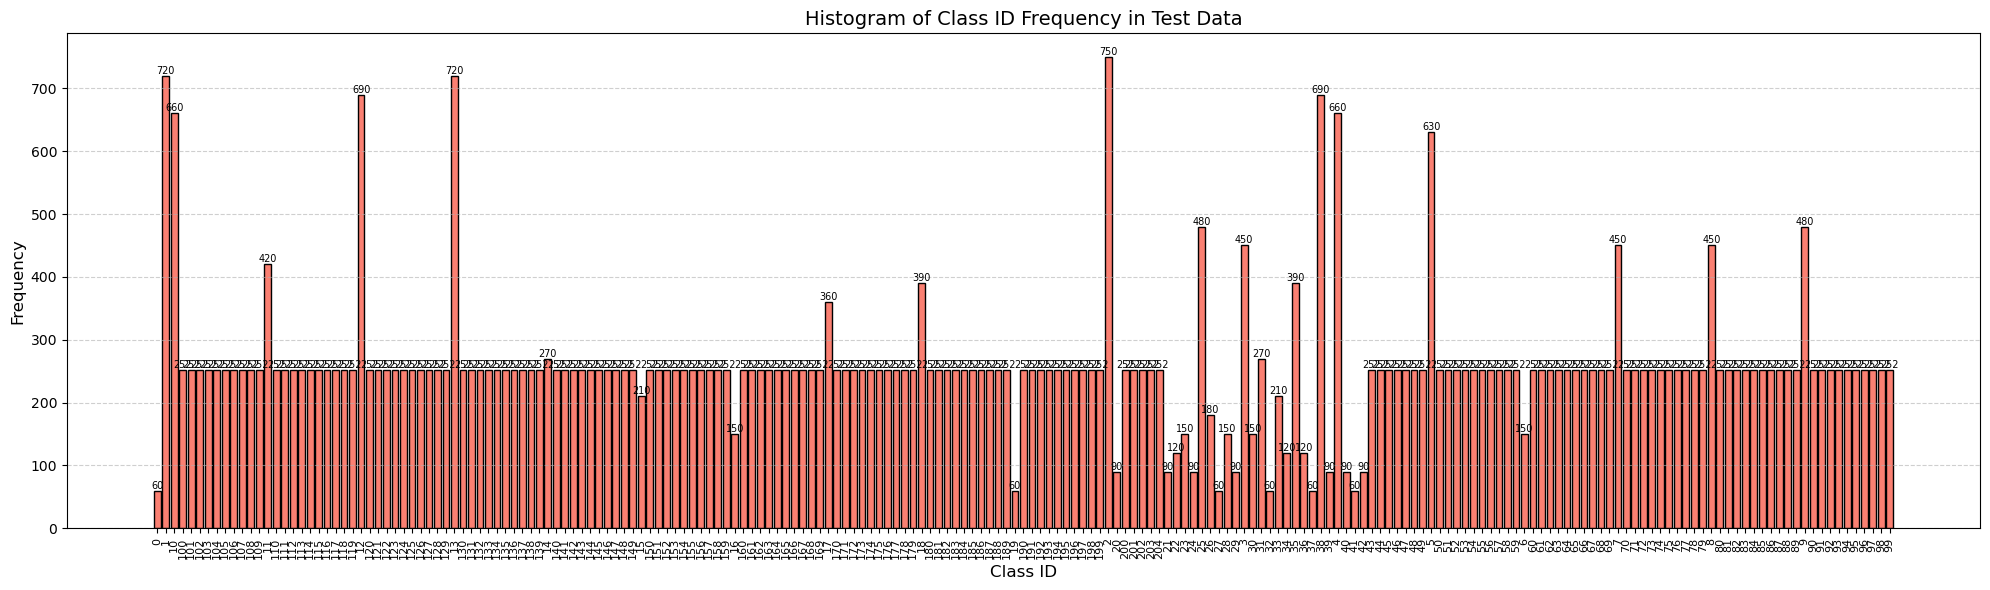

In [19]:
df_test_casted = df.withColumn("ClassId", df["ClassId"].cast("string"))

test_freq = df_test_casted.groupBy("ClassId").count().orderBy("ClassId")
test_freq_pd = test_freq.toPandas()
test_freq_pd["ClassId"] = test_freq_pd["ClassId"].astype(str)

plt.figure(figsize=(20, 6))
bars = plt.bar(test_freq_pd["ClassId"], test_freq_pd["count"], color='salmon', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    if height > 20:
        plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=7)

plt.title("Histogram of Class ID Frequency in Test Data", fontsize=14)
plt.xlabel("Class ID", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

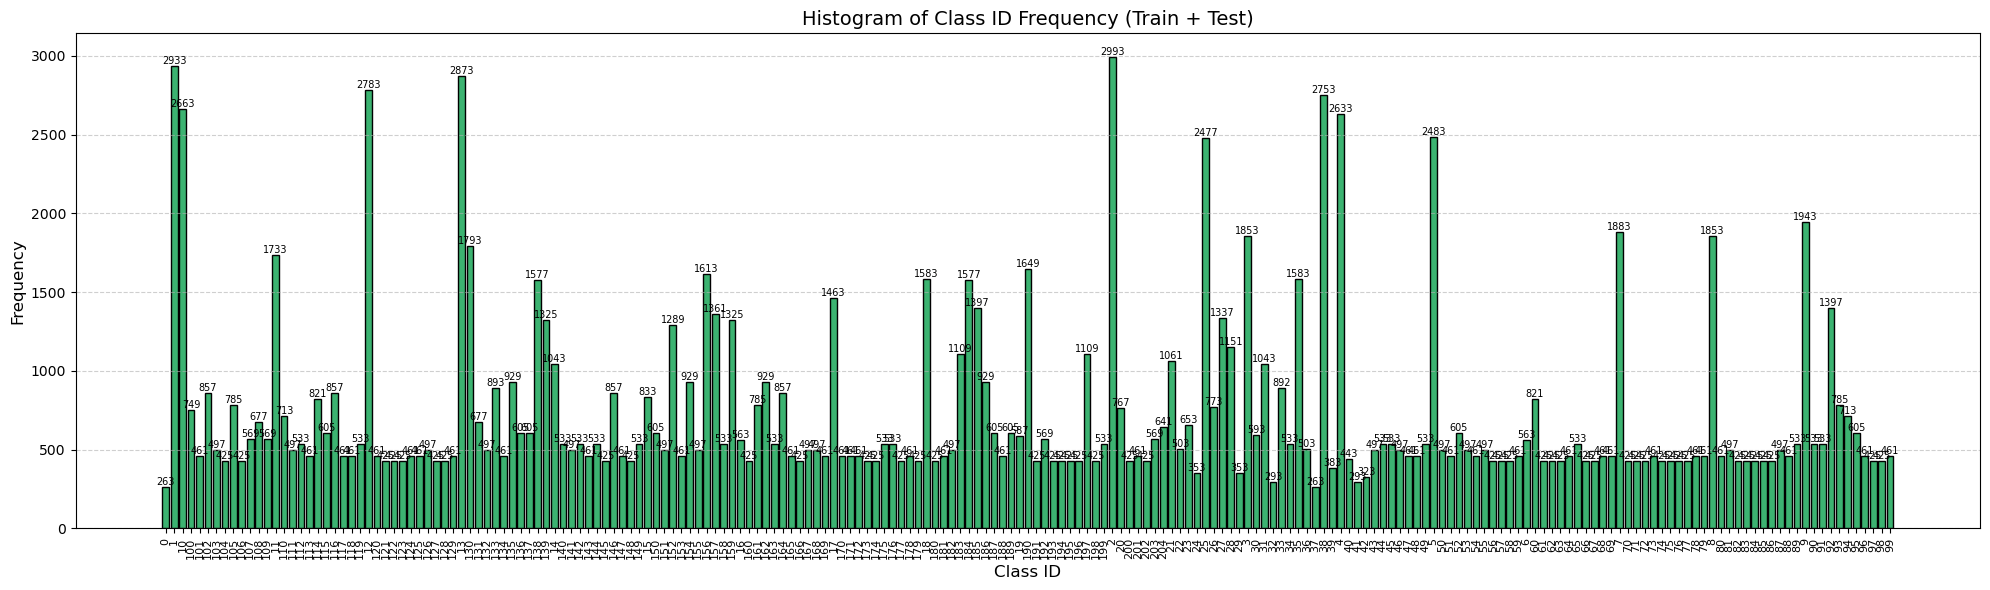

In [20]:
df_train_casted = df_train.withColumn("ClassId", df_train["ClassId"].cast("string"))
df_test_casted = df.withColumn("ClassId", df["ClassId"].cast("string"))
df_all = df_train_casted.select("ClassId").union(df_test_casted.select("ClassId"))

all_freq = df_all.groupBy("ClassId").count().orderBy("ClassId")
all_freq_pd = all_freq.toPandas()
all_freq_pd["ClassId"] = all_freq_pd["ClassId"].astype(str)

plt.figure(figsize=(20, 6))
bars = plt.bar(all_freq_pd["ClassId"], all_freq_pd["count"], color='mediumseagreen', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    if height > 20:
        plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=7)

plt.title("Histogram of Class ID Frequency (Train + Test)", fontsize=14)
plt.xlabel("Class ID", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

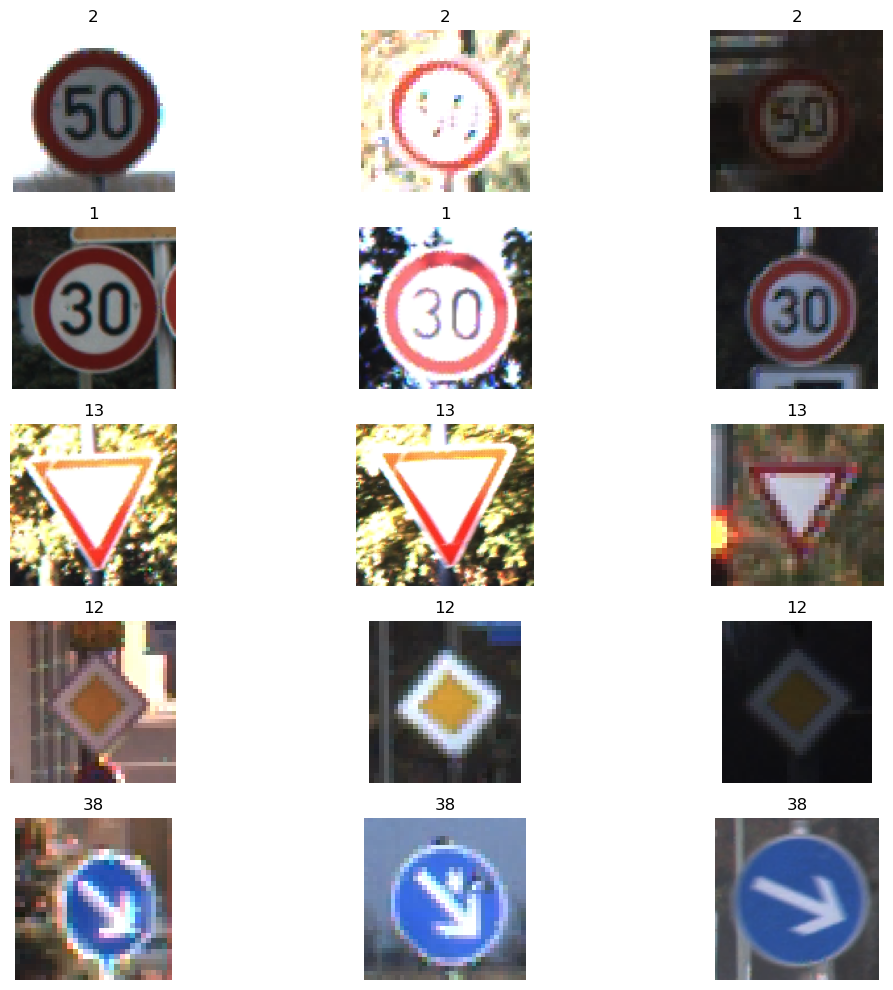

In [21]:
data_images_dir = os.path.dirname(os.path.dirname(path))  

split_folders = [f for f in os.listdir(data_images_dir) if os.path.isdir(os.path.join(data_images_dir, f))]

class_images = defaultdict(list)
for split in split_folders:
    split_dir = os.path.join(data_images_dir, split)
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            images = glob(os.path.join(class_dir, '*'))
            class_images[class_name].extend(images)

class_counts = {cls: len(imgs) for cls, imgs in class_images.items()}

top_classes = [cls for cls, _ in Counter(class_counts).most_common(5)]

fig, axes = plt.subplots(len(top_classes), 3, figsize=(12, 10))
for i, class_name in enumerate(top_classes):
    images = class_images[class_name]
    selected_images = random.sample(images, 3)
    for j, img_path in enumerate(selected_images):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].set_title(class_name)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()